Chronic Heart Disease Prediction

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
import math

%matplotlib inline
print("All packages loaded successfuly!")

All packages loaded successfuly!


Data Exploration:
The Framingham Heart Study dataset contains medical records for 4,238 patients.

Features (X): male, age, education, currentSmoker, cigsPerDay, BPMeds, prevalentStroke, prevalentHyp, diabetes, totChol, sysBP, diaBP, BMI, heartRate, glucose
Target (y): TenYearCHD — 1 if the patient developed coronary heart disease within 10 years, 0 if not.

In [20]:
df = pd.read_excel('heart_disease_data.xlsx') 

print("First five rows of the dataset:")
df.head()

First five rows of the dataset:


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [22]:
print(f"Dataset shape:{df.shape}")                   # This gives us the number of rows and columns
print(f"Number of patients:{df.shape[0]}")           # This gives us the number of rows
print(f"Number of features :{df.shape[1] - 1}")      # This gives us the total number of columns excluding our target variable which is TenYearCHD
print()                                              
print(df.dtypes)                                     # This gives us all the data types of the columns

Dataset shape:(4238, 16)
Number of patients:4238
Number of features :15

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object


In [23]:
print("target variable disribution:")
print(df['TenYearCHD'].value_counts())                            # This helps us determine the number of positive and negative cases for CHD
print()
print(f"CHD Positive Rate: {df['TenYearCHD'].mean()*100:.1f}%")   # Here we are detrmining the rate of positive cases in percenatge(*100) rounded to the
                                                                  # first decimal point (.1f)

target variable disribution:
TenYearCHD
0    3594
1     644
Name: count, dtype: int64

CHD Positive Rate: 15.2%


Text(0, 0.5, 'Number of patients')

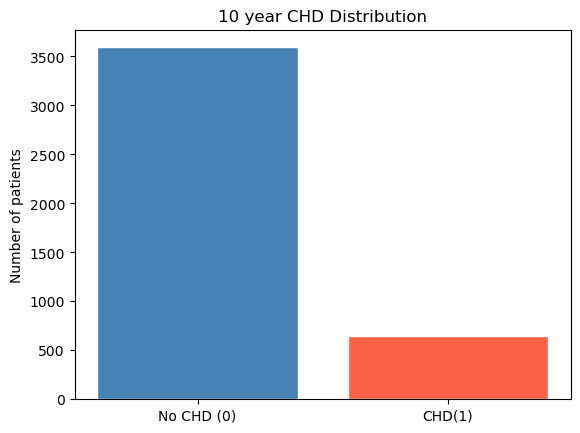

In [24]:
labels = ['No CHD (0)', 'CHD(1)']
counts = df['TenYearCHD'].value_counts().sort_index()
plt.bar(labels,counts,color = ['steelblue','tomato'], edgecolor = 'white')
plt.title('10 year CHD Distribution')
plt.ylabel('Number of patients')

Here we see a bar graph indicating the number of patients that have Chronic heart disease over 10 yearsv/s those without it.

In [25]:
print("Missing values per column")
print(df.isnull().sum())
print(f"\n Total missing: {df.isnull().sum().sum()}")

Missing values per column
male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

 Total missing: 645


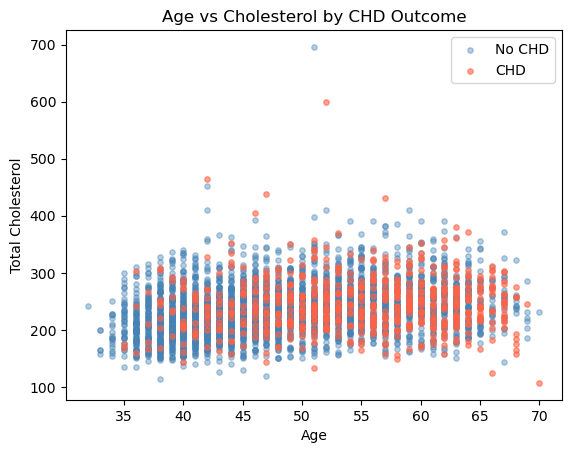

In [26]:
chd_pos = df[df['TenYearCHD'] == 1]
chd_neg = df[df['TenYearCHD'] == 0]

plt.scatter(chd_neg['age'], chd_neg['totChol'], c='steelblue', 
            alpha=0.4, label='No CHD', s=15)
plt.scatter(chd_pos['age'], chd_pos['totChol'], c='tomato', 
            alpha=0.6, label='CHD', s=15)
plt.xlabel('Age')
plt.ylabel('Total Cholesterol')
plt.title('Age vs Cholesterol by CHD Outcome')
plt.legend()
plt.show()

Data Preprocessing

In [27]:
df_clean = df.fillna(df.median())       # Here we are filling out the missing values with the median

print("Missing values after cleaning:")
print(df_clean.isnull().sum().sum())

Missing values after cleaning:
0


In [28]:
X = df_clean.drop('TenYearCHD',axis=1).values  # This removes the target column TenYearCHD
y = df_clean['TenYearCHD'].values              # This keeps just the target column TenYearCHD

print(f"Shape of X: {X.shape}")                # We can see that the number of rows is the same for both X and y but X now has 15 columns instead of 16
print(f"Shape of y: {y.shape}")                # and y has the same number of rows but just the one target column TenYearCHD
print(f"Number of training features (n): {X.shape[1]}")
print(f"Number of examples (m): {X.shape[0]}")

Shape of X: (4238, 15)
Shape of y: (4238,)
Number of training features (n): 15
Number of examples (m): 4238


Normalization - This is done to make sure that the features are on the same scale, as variations may cause gradient descent to slow down

In [29]:
def normalize(X):
    mu = np.mean(X, axis=0)        # Here we are using the mean normalization for all the rows. NOTE: axis = 0 means we are refering to the rows
    sigma = np.std(X, axis=0)
    X_norm = (X - mu)/sigma
    return X_norm,mu,sigma

X_norm,mu,sigma = normalize(X)
print("Features normalized successfully")
print(f"Mean of first feature before: {X[:, 0].mean():.2f}")          # We are checking the mean of the first column/feature before normalixation upto 2 decimal places
print(f"Mean of first feature after: {X_norm[:, 0].mean():.4f}")      # We are checking the mean of the first feature/column after normalization upto
                                                                      # 4 decimal places.

Features normalized successfully
Mean of first feature before: 0.43
Mean of first feature after: -0.0000


Explaination: Imagine that the first feature is [2104, 1600, 2400, 1416], the average(mean) will be 1880. The first print statement give us: What is the average value of the first column before normalization? - Output:Mean of first feature before normalization : 1880.00

What does Normalization Do?
The first part, (X - mu), subtracts the average from every value.:2104 - 1880 = 224
1600 - 1880 = -280
2400 - 1880 = 520
1416 - 1880 = -464

Now the values are:[224, -280, 520, -464]

Notice something:

Some numbers are positive.
Some numbers are negative.
They balance each other out.

The average is now 0.

The second print statement asks us: What is the average value of the first column after normalization? Mean of first feature after normalization: 0
The data has been centered around 0, so normalization worked.

In Other words: Before Normalization:[2104, 1600, 2400, 1416] ; Average = 1880
After Normalization, instead of the actual value we store how far away it is from the average:224 above average
280 below average
520 above average
464 below average
Because everything is measured relative to the average, the new average becomes 0.That's exactly what the second print statement is checking.

We saw the result after subtracting the mean to explain why the average becomes 0.

The actual normalized values would be:[224/sigma, -280/sigma, 520/sigma, -464/sigma]
If sigma = 400, then : [224/400, -280/400, 520/400, -464/400] = [0.56, -0.70, 1.30, -1.16]
The average is still 0; (0.56 - 0.70 + 1.30 - 1.16) / 4 = 0
because dividing every value by the same constant doesn't change the fact that they balance around zero.

Subtracting the mean → makes the mean become 0.
Dividing by the standard deviation → makes the standard deviation become 1.

In [30]:
np.random.seed(42)        # This makes sure that everytime we run the code the shuffle happens the same way so we don't get different values each time.
m = X_norm.shape[0]       # The value of m will be the same as the number of rows, as each row is one data point                               
indices = np.random.permutation(m)    # This helps us obtain a shuffled version or a random permutation of the data but this will be shuffled the same way everytime we run the code and also prevents the training set to contan just one type of data.
split = int(0.8 * m)      # This splits the data into the 80% for training and the remaining 20% as the test data.

train_idx, test_idx = indices[:split], indices[split:]  # This looks at the indices of the test and train parts

X_train, X_test = X_norm[train_idx], X_norm[test_idx]  # This checks the split,i.e the values that go into the train and test part
y_train, y_test = y[train_idx], y[test_idx]

print(f"Training set size:  {X_train.shape[0]}")      # This now checks the size of the test and train part after the split 
print(f"Test set size:      {X_test.shape[0]}")

Training set size:  3390
Test set size:      848


Explaination: This code is splitting your data into training data and test data.

Think of it like the patients that come ito a hospital:

Training set = Existing patients in the hospital with known medical history
Test set = New patients that have never visited the hospital before.

Now: m = X_norm.shape[0] ;If X_norm has 100 rows: m = 100;Each row is one data example.

indices = np.random.permutation(m)- Suppose you have 10 rows:0, 1, 2, 3, 4, 5, 6, 7, 8, 9
After shuffling:[8, 1, 5, 0, 7, 2, 9, 3, 6, 4],This prevents your training set from accidentally containing only one type of data.

split = int(0.8 * m) - If: m = 100,then: split = 80 ;
First 80 rows → training
Last 20 rows → testing

train_idx, test_idx = indices[:split], indices[split:]
Using our shuffled example:indices = [8,1,5,0,7,2,9,3,6,4] and
split = 8
then:

train_idx = [8,1,5,0,7,2,9,3]
test_idx  = [6,4]

X_train = X_norm[train_idx]
X_test = X_norm[test_idx]

This selects the rows corresponding to those indices.

Similarly:

y_train = y[train_idx]
y_test = y[test_idx]
gets the matching target values.

Sigmoid Function:
Recall that for logistic regression, the model is: fw,b(x)=g(w⋅x+b) 
where  g  is the sigmoid function: g(z)=1/(1+e^−z) 

The sigmoid squashes any value to be between 0 and 1, which we interpret as a probability.

In [31]:
def sigmoid(z):
    g = 1/(1 + np.exp(-z))    # z is a scalar or a numpy array of any size
    return g                  # sigmoid(z) is the same shape as z

In [32]:
print(f"sigmoid(0) = {sigmoid(0)}")                # Testing different values of z
print(f"sigmoid(100) = {sigmoid(100):.4f}")
print(f"sigmoid(-100) = {sigmoid(-100):.4f}")
print(f"sigmoid([-1,0,1,2]) = {sigmoid(np.array([-1, 0, 1, 2]))}") # Here we have an array for z instead of a single value

sigmoid(0) = 0.5
sigmoid(100) = 1.0000
sigmoid(-100) = 0.0000
sigmoid([-1,0,1,2]) = [0.26894142 0.5        0.73105858 0.88079708]


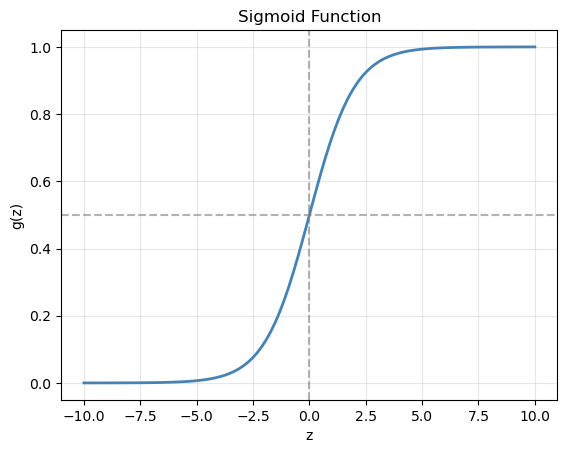

In [33]:
z = np.linspace(-10, 10, 100)
plt.plot(z, sigmoid(z), color='steelblue', linewidth=2)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.6)
plt.axvline(0, color='gray', linestyle='--', alpha=0.6)
plt.xlabel('z')
plt.ylabel('g(z)')
plt.title('Sigmoid Function')
plt.grid(True, alpha=0.3)
plt.show()

Logistic Regression Cost Function:
J(w,b)=1/m∑i[−y(i)log(fw,b(x(i)))−(1−y(i))log(1−fw,b(x(i)))] , where i varies from 0 to m-1

This penalizes wrong predictions heavily — if the true label is 1 but we predict close to 0, the cost shoots up.

In [34]:
def compute_cost(X,y,w,b):              # This tells us how bad our prediction is 
    m = X.shape[0]                      # Here X = training data , y = actual data, w = weights , b = bias
    total_cost = 0.0

    for i in range(m):
        z_i = np.dot(X[i],w) + b
        f_wb_i = sigmoid(z_i)
        total_cost += -y[i] * np.log(f_wb_i) - (1 - y[i])*np.log(1 - f_wb_i)

    cost = total_cost/m
    return cost

In [35]:
m,n = X_train.shape         # Testing the cost function
w_init = np.zeros(n)        # here we have considered the training sets of x and y and assumed w and b values to be 0
b_init = 0.0

initial_cost = compute_cost(X_train,y_train,w_init,b_init)
print(f"Initial cost at (w=0,b=0) :{initial_cost:.4f}")        

Initial cost at (w=0,b=0) :0.6931


Gradient Descent

We update the weights by computing gradients and stepping in the direction that reduces cost:

∂J/∂wj=1/m∑i(fw,b(x(i))−y(i))x(i)j    , where i varies from 0 to m-1

∂J/∂b=1/m∑i(fw,b(x(i))−y(i)) 


In [36]:
def compute_gradient(X, y, w, b):  # This tells us how to improve our predictions
    m,n = X.shape
    dj_dw = np.zeros(n)            # dj_dw is the gradient wrt w
    dj_db = 0.0                    # dj_db is the gradient wrt b

    for i in range(m):
        z_i = np.dot(X[i],w) + b
        f_wb_i = sigmoid(z_i)
        error_i = f_wb_i - y[i]
        dj_dw += error_i * X[i]
        dj_db += error_i

        
    dj_dw /= m
    dj_db /= m
    
    return dj_dw, dj_db

In [37]:
dj_dw,dj_db = compute_gradient(X_train,y_train,w_init,b_init)
print(f"Initial weights : {dj_db:.4f}")
print(f"First 3 elements of dj_dw: {dj_dw[:3]}")

Initial weights : 0.3478
First 3 elements of dj_dw: [-0.03041898 -0.07670141  0.01382797]


Explaination: This function calculates the gradient, which tells the model:
"Which direction should I move the weights and bias to reduce prediction errors?"

Think of it like standing on a hill and trying to get to the bottom. The gradient tells you which way is downhill.

def compute_gradient(X, y, w, b): Here X = feature values (age, cholestrol, smoker...)
y = actual labels (0 or 1  for has CHD)
w = current weights
b = current bias

m,n = X.shape - This gives us the dimesnion of the data,i.e if we have 15 features(smoker, age, cholestrol, diabetes, BP)and 4000 rows we get the shape as m = 4000 and n = 15

dj_dw = np.zeros(n)    : Initially dj_dw = [0, 0, 0] and       
dj_db = 0.0            : dj_db = 0 
These will accumulate information about how wrong the model is.

for i in range(m): Look at one training example at a time.

z_i = np.dot(X[i],w) + b : Recall logistic regression formula: z = w1x1 + w2x2 + ... +b - This computes prediction before sigmoid
eg: X[i] = [2, 3]
w    = [0.5, 0.2]
b    = 1
then z_i = 2(0.5) + 3(0.2) + 1 = 2.6

f_wb_i = sigmoid(z_i) - This converts to a probability
σ(z)=1/1+e^−z
e.g :if z_i = 2.6, then f_wb_i ≈ 0.93- This would mean the model thinks that there ia a 93% chance of someone having CHD

error_i = f_wb_i - y[i]- This calculates the error
suppose: prediction = 0.93
actual = 1
error_i = 0.93 - 1
        = -0.07 which is a small error
but if prediction = 0.90
actual = 0
error_i = 0.90 which is a large error

dj_dw += error_i * X[i] - This adds the contribution from this training example.
e.g: error_i = 0.5
X[i] = [2, 3], then
error_i * X[i] = [1.0, 1.5]

we then add it to dj_dw :  We're accumulating how each feature contributes to the error.

dj_db += error_i: Updating the bias
if errors = [0.2, -0.1, 0.3] then dj_db = 0.4

dj_dw /= m : Averaging out the gradients 
dj_db /= m
if dj_dw = [20, 30, 10]
m = 100
then dj_dw = [0.2, 0.3, 0.1] : This makes the gradients independent of dataset size.

return dj_dw, dj_db: return the gradients
e.g: dj_dw = [0.12, -0.05, 0.21]
     dj_db = -0.03
These values tell gradient descent how to adjust the parameters.

What do these gradients mean?
Suppose:dj_dw = [0.4, -0.2]
dj_db = 0.1
First weight is too large → decrease it.
Second weight is too small → increase it.
Bias is too large → decrease it.
Gradient descent will do:
w = w - alpha * dj_dw
b = b - alpha * dj_db

alpha is the learning rate

dj_dw, dj_db = compute_gradient(X_train, y_train, w_init, b_init): Computes gradients using the initial weights and bias.

print(f"dj_db at initial weights: {dj_db:.4f}")
dj_db at initial weights: -0.1423

This is the average gradient for the bias

print(f"First 3 elements of dj_dw: {dj_dw[:3]}")
First 3 elements of dj_dw: [ 0.23 -0.15 0.08 ]

This just shows the first three weight gradients so you can verify the function is producing sensible numbers.

compute_gradient() looks at every training example, measures how wrong the prediction is, and calculates how each weight and the bias should change to make future predictions more accurate.

In [38]:
def gradient_descent(X,y,w_in,b_in,alpha,num_iters):          # This repeatedly helps make small improvements until our model gets better
    w = copy.deepcopy(w_in)
    b = b_in
    J_history = []

    for i in range(num_iters):
        dj_dw,dj_db = compute_gradient(X,y,w,b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X,y,w,b)
        J_history.append(cost)

        if i%100 == 0:
            print(f"Iteration : {i:4d} | Cost: {cost:.6f}")
            
    return w,b,J_history
print("Gradient Descent Function defined.")

Gradient Descent Function defined.


gradient_descent() repeatedly makes small improvements until the model gets better.

You start with random weights and bias:w = [0, 0, 0, ...]
b = 0
These won't make good predictions.
Gradient descent gradually adjusts them to reduce the error.

w = copy.deepcopy(w_in)     Copy the initial weights
b = b_in
If w_in = [0, 0, 0] and b_in = 0, then w = [0, 0, 0] b = 0 The copy ensures the original values aren't changed.

J_history = []  Create a place to store costs
e.g This will store:[0.69, 0.61, 0.54, 0.49, ...]  so you can see whether the model is improving.

for i in range(num_iters):    Repeat many times, each time the loop runs the model learns
num_iters = 1000

dj_dw, dj_db = compute_gradient(X, y, w, b)  This asks:Given my current weights and bias, which direction should I move them?
e.g dj_dw = [0.5, -0.2] and dj_db = 0.1

w = w - alpha * dj_dw This is the most important line.
suppose, w = [1.0, 2.0] , alpha = 0.1 and dj_dw = [0.5, -0.2]
then w = [1.0, 2.0] - 0.1*[0.5, -0.2]
w = [0.95, 2.02]
The weights move slightly in the direction that reduces error.

b = b - alpha * dj_db
b = 1.0
dj_db = 0.1
alpha = 0.1

Suppose, b = 1.0
dj_db = 0.1
alpha = 0.1
then b = 1.0 - 0.1(0.1) 
b = 0.99  Again, a small adjustment.

What is alpha?
alpha = 0.1  is the learning rate. 
Think of it as your step size. alpha = 0.00001 Too small, Tiny steps.Learning is very slow.

alpha = 100 Too large,Huge jumps.You might overshoot the best solution and never converge.

alpha = 0.01. Just right.Reasonable progress toward the minimum cost.

cost = compute_cost(X, y, w, b)  Calculate current cost.This measures:How wrong is the model right now?
e.g cost = 0.693
after a few updates:cost = 0.500
later:cost = 0.200  Lower is better.

J_history.append(cost):  Save the cost
This creates something like:
J_history =
[
  0.693,
  0.650,
  0.620,
  0.590,
  ...
] this is Useful for plotting the learning curve later.

if i % 100 == 0:     Print progress every 100 iterations. The % operator means remainder.
100 % 100 = 0
200 % 100 = 0
350 % 100 = 50
So it prints only when:
i = 0
100
200
300
...

print(f"Iteration {i:4d} | Cost: {cost:.6f}")
output: Iteration    0 | Cost: 0.693147
Iteration  100 | Cost: 0.421584
Iteration  200 | Cost: 0.298113
Iteration  300 | Cost: 0.221004
This lets you verify the cost is decreasing.

return w, b, J_history   Return results
After training, you get:
w = learned weights
b = learned bias
J_history = all costs
These learned weights can now make predictions on new data.

Train The Model

In [39]:
np.random.seed(42)
w_init = np.zeros(X_train.shape[1])
b_init = 0.0
alpha = 0.01      # Learning rate
num_iters = 1000  # Number of iterations

print("Training logistic regression...")
print("-" * 40)
w, b, J_history = gradient_descent(X_train, y_train, w_init, b_init, alpha, num_iters)
print("-" * 40)
print(f"\nFinal cost: {J_history[-1]:.6f}")

Training logistic regression...
----------------------------------------
Iteration :    0 | Cost: 0.691667
Iteration :  100 | Cost: 0.581674
Iteration :  200 | Cost: 0.518050
Iteration :  300 | Cost: 0.478269
Iteration :  400 | Cost: 0.452154
Iteration :  500 | Cost: 0.434381
Iteration :  600 | Cost: 0.421922
Iteration :  700 | Cost: 0.412965
Iteration :  800 | Cost: 0.406383
Iteration :  900 | Cost: 0.401453
----------------------------------------

Final cost: 0.397730


This block is where you set up the training and then start the learning process.

w_init = np.zeros(X_train.shape[1])       Initialize weights
Suppose your dataset has:4 features, then X_train.shape[1] = 4 and w_init = [0, 0, 0, 0], this means Start with all weights equal to zero

b_init = 0.0, do initially b = 0

alpha = 0.01 Set the learning rate, this means Move 1% of the gradient amount each update

num_iters = 1000 This means:Update the weights and bias 1000 times.

print("-" * 40) The * 40 repeats the dash 40 times.Just for readability.

w, b, J_history = gradient_descent(          Train the model: This is the important line.Use my training data and repeatedly adjust the weights and 
    X_train,                                 bias until the model learns
    y_train,      
    w_init,
    b_init,
    alpha,
    num_iters
)

w = learned weights
b = learned bias
J_history = costs from all iterations

print(f"\nFinal cost: {J_history[-1]:.6f}") What does [-1] mean? Give me the last item in the list.
if J_history =
[ 0.693,
0.621,
0.510,
0.420,
0.350
] then J_history[-1] is 0.350

After 1000 learning steps, the model's error is about 0.397
Lower cost generally means the model is fitting the training data better.

So this block doesn't contain any new machine-learning math—it simply sets the training parameters and launches the gradient descent algorithm you defined earlier.


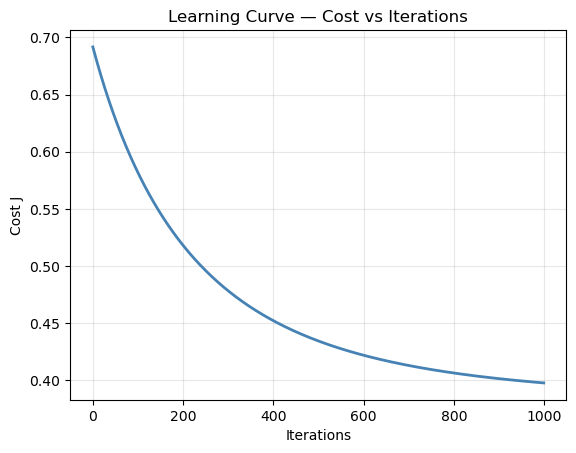

Cost should be steadily decreasing. If not, try a smaller learning rate alpha.


In [40]:
plt.plot(range(len(J_history)), J_history, color='steelblue', linewidth=2)
plt.xlabel('Iterations')
plt.ylabel('Cost J')
plt.title('Learning Curve — Cost vs Iterations')
plt.grid(True, alpha=0.3)
plt.show()
print("Cost should be steadily decreasing. If not, try a smaller learning rate alpha.")

This code creates a learning curve, which is simply a graph showing:"Is my model getting better as it trains?"
J_history contains all the costs recorded during training.

The cost should go down as training progresses
the x-axis or the no of iterations tells us: How many gradient descent updates have been completed?
the y-axis or the cost tells us:How much error does the model currently have?Lower values are better.

This code plots the model's error (cost) after each training iteration so you can visually verify that gradient descent is successfully reducing the error over time.

In [52]:
# View the learned weights
feature_names = df_clean.drop('TenYearCHD', axis=1).columns     # TenYearCHD is the target (what we're trying to predict).This removes the target variable
print("Learned weights (w):")
for name, weight in zip(feature_names, w):
    print(f"  {name:20s}: {weight:+.4f}")                   # {name:20s} means Print the feature name using 20 character spaces.
print(f"\nLearned bias (b): {b:.4f}")                       # {weight:+.4f} means Show the sign (+ or -)Show 4 decimal places
print("\nHigher absolute weight = more influence on prediction.") # The absolute weight indicates just the magnitude without +ve or -ve and tell us how
                                                                  # much infuence each factor has on the CHD

Learned weights (w):
  male                : +0.1444
  age                 : +0.2746
  education           : -0.0114
  currentSmoker       : +0.0571
  cigsPerDay          : +0.1003
  BPMeds              : +0.0750
  prevalentStroke     : +0.0961
  prevalentHyp        : +0.0998
  diabetes            : +0.0542
  totChol             : +0.0587
  sysBP               : +0.1647
  diaBP               : +0.0391
  BMI                 : -0.0134
  heartRate           : +0.0083
  glucose             : +0.0773

Learned bias (b): -1.4305

Higher absolute weight = more influence on prediction.


This code is showing you what the model learned after training.

for name, weight in zip(feature_names, w):    This line matches each feature with its weight
e.g feature_names = ['Age', 'BMI', 'Glucose', 'Smoking'] and w =[1.2, 0.4, 0.9, -0.3] the zip() pairs them together:
('Age', 1.2)
('BMI', 0.4)
('Glucose', 0.9)
('Smoking', -0.3)

A weight tells you:"How much does this feature influence the prediction?"
+ve value indicates that the model becomes more likely to predict CHD and a -ve value indicates the model becomes less likely to predict CHD.CLoser to 0 means that this feature has close to no influence on the CHD

The bias is the model's baseline starting point.Think of it as:"What's my prediction before looking at any features?"
The weights then adjust that prediction up or down.

Because you normalized the features earlier:comparing weight magnitudes is meaningful.Without normalization, a feature measured in large units (like income in dollars) could appear to have a large weight simply because of its scale.

This code prints each feature alongside the weight learned by logistic regression, allowing you to see which features push predictions up or down and which features have the strongest influence on the model.

Model Evaluation

In [46]:
def predict(X, w, b, threshold=0.5):
    m = X.shape[0]                                        # This gives me the number of rows, so if the data set has 4000 rows m = 4000
    predictions = np.zeros(m)                             # This creates storage for predictions

    for i in range(m):                                    # We loop through one patient at a time and perform the logistic regression like before
        z_i = np.dot(X[i], w) + b                         # the sigmoid function will convert the probability into a value between 0 and 1
        prob_i = sigmoid(z_i)                             # We then check of this probability is greater than 0.5 or less and classify it accordingly.
        predictions[i] = 1 if prob_i >= threshold else 0  # NOTE: If we choose a higher threshold for probability to make sure that of the probability 
                                                          # of CHD for 1 patient is 0.45 and the other is 0.51 then both get classified into different classes
                                                          # even though the difference between the two is not much and since we are dealing with medical data
                                                          # even if someone who does not have CHD gets calssified as having it is better than someone who
    return predictions                                    # has it and is not diagnosed.
                                                          # the return will give us [1,0,1,1,....]


# Predict on train and test sets
y_pred_train = predict(X_train, w, b, threshold = 0.5)   # We now predict using the training set and the model has already seen this data
y_pred_test  = predict(X_test, w, b,threshold = 0.5)     # The test set prediction is data the model has never seen before

train_acc = np.mean(y_pred_train == y_train) * 100
test_acc  = np.mean(y_pred_test  == y_test)  * 100

print(f"Training accuracy: {train_acc:.2f}%")
print(f"Test accuracy:     {test_acc:.2f}%")

Training accuracy: 85.28%
Test accuracy:     85.50%


In [47]:
# Confusion Matrix with default 0.5 threshold
def confusion_matrix_manual(y_true, y_pred):
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    return TP, TN, FP, FN

TP, TN, FP, FN = confusion_matrix_manual(y_test, y_pred_test)

print("Confusion Matrix (Test Set):")
print(f"                 Predicted No   Predicted Yes")      # This creates column headers
print(f"Actual No    :        {TN:4d}           {FP:4d}")    # If we look at the output we see that we have 626 healthy patients correctly identified(TN)
print(f"Actual Yes   :        {FN:4d}           {TP:4d}")    # 94 healthy patients falsely flagged(FP),83 CHD patients missed (FN) and 45 patients 
print()                                                      # correctly identified (TP)

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision : {precision:.4f}  (of patients we predicted CHD, how many actually had it)")
print(f"Recall    : {recall:.4f}  (of actual CHD patients, how many did we catch)")
print(f"F1 Score  : {f1:.4f}")

Confusion Matrix (Test Set):
                 Predicted No   Predicted Yes
Actual No    :         716              4
Actual Yes   :         119              9

Precision : 0.6923  (of patients we predicted CHD, how many actually had it)
Recall    : 0.0703  (of actual CHD patients, how many did we catch)
F1 Score  : 0.1277


Although the confusion matrix at the default threshold of 0.5 produced poor recall (7%), the ROC curve(below) achieved an AUC of 0.76, indicating that the logistic regression model possesses reasonable discriminatory power. This suggests that the model is capable of ranking high-risk patients above low-risk patients, but the chosen classification threshold is too conservative. Further threshold tuning could improve sensitivity and increase detection of CHD cases.

In [43]:
def predict(X, w, b, threshold=0.5):
    m = X.shape[0]                                        # This code is the same as the one above and is used to compare the outputs while using 
    predictions = np.zeros(m)                             # different thresholds. The threshold i the funcion is left to its default value of 0.5
                                                          # but when we call the function we use 0.3 as our threshold. As we can see in the output we get
    for i in range(m):                                    # different values for training and testing accuracy.Even though in the previous code we see 
        z_i = np.dot(X[i], w) + b                         # that we get a higher training and testing accuracy, notice how in both cases the values are
        prob_i = sigmoid(z_i)                             # still close to each other. The advantage of a lower threshold will be seen later when we 
        predictions[i] = 1 if prob_i >= threshold else 0  # measure f1,precision and recall.
                                                          
                                                          
    return predictions                                    
                                                          


# Predict on train and test sets
y_pred_train = predict(X_train, w, b, threshold = 0.3)   # We now predict using the training set and the model has already seen this data
y_pred_test  = predict(X_test, w, b,threshold = 0.3)     # The test set prediction is data the model has never seen before

train_acc = np.mean(y_pred_train == y_train) * 100
test_acc  = np.mean(y_pred_test  == y_test)  * 100

print(f"Training accuracy: {train_acc:.2f}%")
print(f"Test accuracy:     {test_acc:.2f}%")

Training accuracy: 80.59%
Test accuracy:     79.13%


This section is checking:"Now that the model has learned, how well does it actually perform?"

Training set = patients already in the hospital system.
Test set = new patients you've never seen before.
A good model should perform well on both.

def predict(X, w, b, threshold=0.3):This function takes:X = feature values, w = learned weights, b = learned bias, threshold = 0.3 and returns predictions:0 or 1

train_acc = np.mean(y_pred_train == y_train) * 100          : Calculate training accuracy
e.g : y_pred_train = [1,0,1,1]
y_train      = [1,0,0,1]

y_pred_train == y_train compare them, we get [True, True, False, True]
or 
Correct
Correct
Wrong
Correct

np.mean(...)  Compute average
In NumPy True  = 1, False = 0 so [1,1,0,1] and avg = 3/4 = 0.75. If we convert to a percentage we get 0.75 * 100 = 75
The model got 75% of the training examples correct.In our case the training accuracy is 80.59%

Similarly for test accuracy in this case we get 79.13%

If we see here our training and testing numbers are close to each other this means The model generalizes well to new data.

If we had values like: Training accuracy: 99% , Test accuracy: 70% this would be overfitting.The model memorized the training data.It doesn't perform well on unseen data.

If we had values like :Training accuracy: 60%, Test accuracy: 58%, this would be underfitting. The model isn't learning enough.Both scores are low.

Why do we care more about test accuracy?
Because the training set was used for learning.
The test set is the first truly fair evaluation.
It's answering:"If I give the model a brand-new patient it has never seen before, how often will it make the correct prediction?"

Confusion Matrix

In [44]:
# Confusion Matrix with new Threshold(0.3)
def confusion_matrix_manual(y_true, y_pred):
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    return TP, TN, FP, FN

TP, TN, FP, FN = confusion_matrix_manual(y_test, y_pred_test)

print("Confusion Matrix (Test Set):")
print(f"                 Predicted No   Predicted Yes")      # This creates column headers
print(f"Actual No    :        {TN:4d}           {FP:4d}")    # If we look at the output we see that we have 626 healthy patients correctly identified(TN)
print(f"Actual Yes   :        {FN:4d}           {TP:4d}")    # 94 healthy patients falsely flagged(FP),83 CHD patients missed (FN) and 45 patients 
print()                                                      # correctly identified (TP)

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision : {precision:.4f}  (of patients we predicted CHD, how many actually had it)")
print(f"Recall    : {recall:.4f}  (of actual CHD patients, how many did we catch)")
print(f"F1 Score  : {f1:.4f}")

Confusion Matrix (Test Set):
                 Predicted No   Predicted Yes
Actual No    :         626             94
Actual Yes   :          83             45

Precision : 0.3237  (of patients we predicted CHD, how many actually had it)
Recall    : 0.3516  (of actual CHD patients, how many did we catch)
F1 Score  : 0.3371


This section goes beyond simple accuracy and answers:"What kinds of mistakes is the model making?"
For medical predictions like CHD (Coronary Heart Disease), this is often more important than accuracy.

What is a Confusion Matrix?

After making predictions, there are 4 possible outcomes:

Actual	Predicted	Result
No CHD	No CHD	   Correct
No CHD	CHD	       False Alarm
CHD	    CHD	       Correct
CHD	    No CHD	    Missed Patient

These correspond to:
TP = True Positive
TN = True Negative
FP = False Positive
FN = False Negative

def confusion_matrix_manual(y_true, y_pred):    y_true = actual answers, y_pred = model predictions
e.g y_true = [1,0,1,0,1]
y_pred = [1,1,1,0,0]

Calculate TP (True Positives): TP = np.sum((y_pred == 1) & (y_true == 1))  This counts:"How many CHD patients were correctly identified?"
Actual = 1
Predicted = 1  Correct
e.g y_true = [1,0,1,0,1], y_pred = [1,1,1,0,0]
Patient 1: Actual=1 Predicted=1
Patient 3: Actual=1 Predicted=1, so TP = 2

Calculate TN (True Negatives): TN = np.sum((y_pred == 0) & (y_true == 0))  This Counts: "How many healthy patients were correctly identified?"
Actual = 0
Predicted = 0  Correct
e.g Patient 4: Actual=0 Predicted=0, so, TN = 1

Calculate FP (False Positives): FP = np.sum((y_pred == 1) & (y_true == 0)) This Counts:"How many healthy patients were incorrectly labeled as CHD?"
Actual = 0
Predicted = 1 False Alarm
e.g Patient 2: Actual=0 Predicted=1 so, FP = 1

Calculate FN (False Negatives): FN = np.sum((y_pred == 0) & (y_true == 1)) This Counts: "How many CHD patients did the model miss?"
Actual = 1
Predicted = 0 Dangerous mistake
e.g Patient 5: Actual=1 Predicted=0 so, FN = 1

return TP, TN, FP, FN
TP = 2
TN = 1
FP = 1
FN = 1

TP, TN, FP, FN = confusion_matrix_manual(y_test, y_pred_test)  This evaluates the model on the test set.

Precision: precision = TP / (TP + FP), meaning "When the model says someone has CHD, how often is it correct?"
e.g In our case  TP = 45,FP = 94, then precision = 45/(45+94) = 0.3237
So 32.37% of positive predictions were correct.

Recall: recall = TP / (TP + FN), meaning "Of all patients who truly had CHD, how many did we find?"
TP = 45
FN = 83,then recall = 45/(45+83) = 0.3516. So the model found 35.16% of CHD patients

Why recall matters in medicine. Missing a sick patient is usually worse than a false alarm.So in healthcare we often care a lot about recall because it measures how many actual cases we catch.

F1 Score: f1 = 2 * precision * recall / (precision + recall)
precision = 0.32237
recall = 0.3516
f1 = 0.3371

Why not just use accuracy?
Suppose: we have 100 patients
Only 5 have CHD, 95 do not
A dumb model could predict: Everyone is healthy and get: 95% accuracy. But it would catch:0 CHD patients.which is terrible.That's why we also look at:
Precision, Recall, F1 Score, Confusion Matrix


C:\Users\prach\AppData\Local\Temp\ipykernel_22948\1066755950.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = abs(np.trapz(tpr_list, fpr_list))


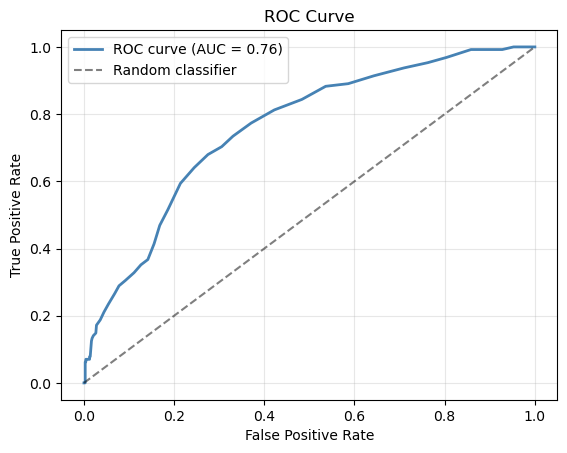

AUC = 0.7572  (closer to 1.0 = better model)


In [48]:
# ROC Curve
def compute_probabilities(X, w, b):
    probs = np.array([sigmoid(np.dot(X[i], w) + b) for i in range(X.shape[0])])
    return probs

y_probs = compute_probabilities(X_test, w, b)

thresholds = np.linspace(0, 1, 100)
tpr_list, fpr_list = [], []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    TP_t = np.sum((y_pred_t == 1) & (y_test == 1))
    TN_t = np.sum((y_pred_t == 0) & (y_test == 0))
    FP_t = np.sum((y_pred_t == 1) & (y_test == 0))
    FN_t = np.sum((y_pred_t == 0) & (y_test == 1))
    tpr_list.append(TP_t / (TP_t + FN_t + 1e-9))
    fpr_list.append(FP_t / (FP_t + TN_t + 1e-9))

# Compute AUC using trapezoidal rule
auc = abs(np.trapz(tpr_list, fpr_list))

plt.plot(fpr_list, tpr_list, color='steelblue', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random classifier')           # here we are setting up random claffier basically drawing a random line
plt.xlabel('False Positive Rate')                                               # and saying that our model should be above this line
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f"AUC = {auc:.4f}  (closer to 1.0 = better model)")

The ROC curve is a graph.AUC measures the area underneath it.
If AUC = 1 ,its a perfect model.If AUC < 0.5 Something is very wrong.

The graph means : How many false alarms? vs How many CHD cases found?

How to interpret AUC
AUC	Meaning
0.50	Random guessing
0.60	Weak
0.70	Fair
0.80	Good
0.90	Excellent
1.00	Perfect

The ROC curve tells you:"If I lower the threshold, can I catch more CHD patients?"
A good ROC curve means:The model actually knows something useful.Even if the current threshold is bad.

Suppose our ROC AUC is:0.82. That means:The model is actually pretty good at separating CHD and non-CHD patients.The issue is not the model itself.
The issue is the threshold and we can dramtically improve the recall by changing the threshold.

the ROC curve is saying:"The model actually knows how to separate CHD from non-CHD patients reasonably well.
Think of it this way

Suppose the model outputs with a 0.23 threshold

Patient	Probability
Healthy-	0.05
Healthy-	0.12
Healthy-	0.20
CHD-     	0.35
CHD-    	0.40
CHD-     	0.45

The model is ranking CHD patients higher than healthy patients.That's good.But with threshold = 0.5 every patient gets classified as No CHD because no patient reaches 0.5

What happened?
By lowering the threshold from:0.5 → 0.3

you told the model:"I'm willing to predict CHD even if I'm only 30% confident."

As a result:Good news:You caught many more CHD patients:

Before:  9
After:  45

Recall increased from:7% to 35%

That's a 5× improvement.

Bad news:You also created more false alarms:FP:4 → 94

Precision dropped:69% to 32%

Meaning: When the model predicts CHD, it's correct only about one-third of the time.

Which threshold is better?For a medical screening problem:

Threshold = 0.5,Found 9 CHD patients and Missed 119 CHD patients

Not very useful.

Threshold = 0.3,Found 45 CHD patients,Missed 83 CHD patients

Still not great, but much better.

Most clinicians would prefer this over the first model because missing disease is often more costly than a false alarm.

Your AUC of 0.76 predicted this

Remember: AUC = 0.757

The ROC curve suggested:"The model has some ability to separate CHD and non-CHD patients."

And that's exactly what happened.

By moving the threshold, we unlocked more of that predictive ability.

I'd test a few more thresholds

In [61]:
# Test multiple thresholds 

for t in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15]:                      # Here we are testing multiple thresholds and we select the one with the highest f1
                                                                # score as it balences both precision and recall and is the best metric for imbalenced
    y_pred = predict(X_test, w, b, threshold=t)                 # classification problems. 

    TP, TN, FP, FN = confusion_matrix_manual(y_test, y_pred)    # Here we can see that of the given values that we have tested 0.25 gives us the highest
                                                                # f1 score, but is this the best threshold?
    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    print(f"Threshold = {t:.2f}")
    print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")
    print(f"Precision = {precision:.3f}")
    print(f"Recall    = {recall:.3f}")
    print(f"F1 Score  = {f1:.3f}")
    print("-" * 40)

Threshold = 0.50
TP=9, TN=716, FP=4, FN=119
Precision = 0.692
Recall    = 0.070
F1 Score  = 0.128
----------------------------------------
Threshold = 0.40
TP=21, TN=700, FP=20, FN=107
Precision = 0.512
Recall    = 0.164
F1 Score  = 0.249
----------------------------------------
Threshold = 0.30
TP=45, TN=626, FP=94, FN=83
Precision = 0.324
Recall    = 0.352
F1 Score  = 0.337
----------------------------------------
Threshold = 0.25
TP=76, TN=561, FP=159, FN=52
Precision = 0.323
Recall    = 0.594
F1 Score  = 0.419
----------------------------------------
Threshold = 0.20
TP=101, TN=445, FP=275, FN=27
Precision = 0.269
Recall    = 0.789
F1 Score  = 0.401
----------------------------------------
Threshold = 0.15
TP=117, TN=254, FP=466, FN=11
Precision = 0.201
Recall    = 0.914
F1 Score  = 0.329
----------------------------------------


In [45]:
best_threshold = None
best_f1 = 0

for t in np.arange(0.05, 0.95, 0.01):                   # Here we test thresholds from the range 0.01 - 0.95 to determine the best threshold. 
                                                        # NOTE: Even though we have a larger range we should not have a threshold that is too high or
    y_pred = predict(X_test, w, b, threshold=t)         # low in order to avoid misclassifications.

    TP, TN, FP, FN = confusion_matrix_manual(y_test, y_pred)

    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Best Threshold = {best_threshold:.2f}")       # Here we can see that the best threshold is 0.23
print(f"Best F1 Score = {best_f1:.4f}")

Best Threshold = 0.23
Best F1 Score = 0.4231


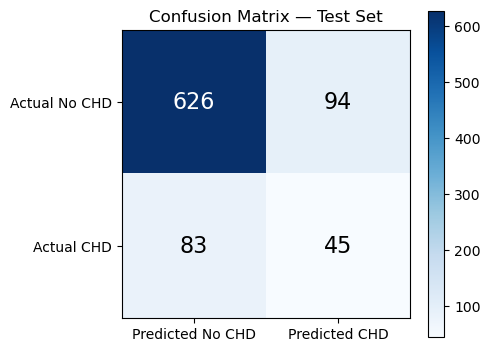

In [59]:
# Plot confusion matrix as heatmap - 0.3 threshold
cm = np.array([[TN, FP], [FN, TP]])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)
ax.set_xticks([0, 1])     
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted No CHD', 'Predicted CHD'])
ax.set_yticklabels(['Actual No CHD', 'Actual CHD'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', 
                fontsize=16, color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

Threshold = 0.23
TP=88, TN=520, FP=200, FN=40
Precision = 0.306
Recall = 0.687
F1 = 0.423


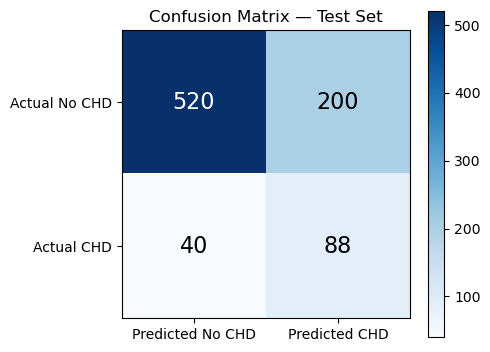

In [64]:
# Best Threshold Confusion Matrix
best_t = 0.23

y_pred_best = predict(X_test, w, b, threshold=best_t)

TP, TN, FP, FN = confusion_matrix_manual(y_test, y_pred_best)

precision = TP / (TP + FP + 1e-9)
recall = TP / (TP + FN + 1e-9)
f1 = 2 * precision * recall / (precision + recall + 1e-9)

print(f"Threshold = {best_t}")
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")
print(f"Precision = {precision:.3f}")
print(f"Recall = {recall:.3f}")
print(f"F1 = {f1:.3f}")

cm = np.array([[TN, FP], [FN, TP]])
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted No CHD', 'Predicted CHD'])
ax.set_yticklabels(['Actual No CHD', 'Actual CHD'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', 
                fontsize=16, color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

The default threshold of 0.5 produced high overall accuracy (85.5%) but very low recall (7%). ROC analysis yielded an AUC of 0.76, indicating reasonable class separability. Threshold tuning showed that lowering the threshold to 0.23 increased recall to 68.7% while achieving the highest F1 score of 0.423, providing a better balance between precision and recall.

What does 0.23 mean?
The default logistic regression threshold is: 0.5.which means:Only predict CHD if the model is at least 50% confident.

Our analysis suggests that a threshold of 0.23 works better Meaning:Predict CHD whenever the model estimates at least a 23% chance of CHD.
Because our dataset is imbalanced (many more No CHD than CHD cases), this lower threshold catches more true CHD patients.

Predictions for a New Patient

In [67]:
def predict_new_patient(patient_data, w, b, mu, sigma):
    """
    Predicts 10-year CHD risk for a new patient.

    Args:
        patient_data (list): Feature values in the same order as training data:
                             [male, age, education, currentSmoker, cigsPerDay,
                              BPMeds, prevalentStroke, prevalentHyp, diabetes,
                              totChol, sysBP, diaBP, BMI, heartRate, glucose]
        w, b        : Learned parameters
        mu, sigma   : Mean and std used for normalization

    Returns:
        probability (float): Probability of developing CHD
        prediction  (int)  : 1 if at risk, 0 if not
    """
    x = np.array(patient_data)
    x_norm = (x - mu) / sigma
    z = np.dot(x_norm, w) + b
    prob = sigmoid(z)
    pred = 1 if prob >= 0.23 else 0
    return prob, pred


# Example: 55-year-old male, smoker, high blood pressure
# [male, age, education, currentSmoker, cigsPerDay, BPMeds,
#  prevalentStroke, prevalentHyp, diabetes, totChol, sysBP, diaBP,
#  BMI, heartRate, glucose]
patient_1 = [1, 55, 2, 1, 20, 0, 0, 1, 0, 240, 145, 90, 27.5, 80, 90]

prob, pred = predict_new_patient(patient_1, w, b, mu, sigma)
print(f"Patient: 55-year-old male, smoker, hypertensive")
print(f"10-year CHD probability : {prob*100:.1f}%")
print(f"Prediction              : {'AT RISK (1)' if pred == 1 else 'NOT AT RISK (0)'}")
print()

# Example: 35-year-old female, non-smoker, healthy
patient_2 = [0, 35, 3, 0, 0, 0, 0, 0, 0, 180, 110, 70, 22.0, 72, 80]
prob2, pred2 = predict_new_patient(patient_2, w, b, mu, sigma)
print(f"Patient: 35-year-old female, non-smoker, healthy")
print(f"10-year CHD probability : {prob2*100:.1f}%")
print(f"Prediction              : {'AT RISK (1)' if pred2 == 1 else 'NOT AT RISK (0)'}")

Patient: 55-year-old male, smoker, hypertensive
10-year CHD probability : 33.8%
Prediction              : AT RISK (1)

Patient: 35-year-old female, non-smoker, healthy
10-year CHD probability : 7.3%
Prediction              : NOT AT RISK (0)
